# Training Model Deteksi Anomali UAV (Multi-Sensor Fusion)
Notebook ini melatih model Deep Learning menggunakan gabungan sensor IMU, Attitude, dan Magnetometer.

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import pickle
import parser_utils

## 1. Membaca dan Memproses Data
Fungsi ini membaca data anomali dari `Fusion_Data.csv` dan mengekstrak data normal dari `.BIN`.

In [11]:
def load_and_preprocess_data(anomaly_file, normal_bin_file):
    print("Membaca data anomali (Fusion_Data.csv)...")
    df_anomaly = pd.read_csv(anomaly_file)
    
    # Pastikan label anomali sudah ada, biasanya kolomnya bernama 'labels'
    if 'labels' in df_anomaly.columns:
        df_anomaly.rename(columns={'labels': 'Label'}, inplace=True)
        
    print("Mengekstrak data normal dari .BIN...")
    # Mengekstrak data penerbangan normal menggunakan parser_utils
    df_normal = parser_utils.extract_fusion_data_from_bin(normal_bin_file)
    df_normal['Label'] = 0
    
    # Kolom fitur/sensor yang akan digunakan
    feature_columns = [
        'DesRoll', 'Roll', 'DesPitch', 'Pitch', 'DesYaw', 'Yaw', 'ErrRP', 'ErrYaw',
        'MagX', 'MagY', 'MagZ',
        'abGyrX', 'abGyrY', 'abGyrZ', 'abAccX', 'abAccY', 'abAccZ'
    ]
    
    for col in feature_columns:
        if col not in df_anomaly.columns:
            df_anomaly[col] = 0.0
        if col not in df_normal.columns:
            df_normal[col] = 0.0
            
    cols_to_keep = feature_columns + ['Label']
    
    df_anomaly = df_anomaly[cols_to_keep]
    df_normal = df_normal[cols_to_keep]
    
    df_combined = pd.concat([df_anomaly, df_normal], ignore_index=True)
    df_combined.fillna(0, inplace=True)
    
    print(f"Total baris data gabungan: {len(df_combined)}")
    print("Distribusi Label:\n", df_combined['Label'].value_counts())
    
    X = df_combined.drop(columns=['Label'])
    y = df_combined['Label']
    
    # Memastikan label dalam rentang 0-4
    y = y.apply(lambda val: int(val) if 0 <= int(val) <= 4 else 1)
    
    return X, y

## 2. Membangun Arsitektur Model (ANN)


In [12]:
def build_model(input_shape):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_shape,)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(5, activation='softmax') 
    ])
    
    model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

## 3. Eksekusi Training


In [13]:
# Path dataset
anomaly_file = 'dataset_anomaly/Fusion_Data.csv'
normal_bin_file = 'datasetUAV/00000019.BIN'

# 1. Load Data
X, y = load_and_preprocess_data(anomaly_file, normal_bin_file)

# 2. Scaling
print("\nMelakukan scaling data (StandardScaler)...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. Build Model
print("Membangun model Jaringan Saraf Tiruan (Deep Learning/MLP)...")
model = build_model(X_train.shape[1])
model.summary()

# 5. Training
print("Memulai proses training...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# 6. Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nAkurasi Test: {accuracy:.4f}")

Membaca data anomali (Fusion_Data.csv)...
Mengekstrak data normal dari .BIN...
Total baris data gabungan: 18819
Distribusi Label:
 Label
0    13133
2     1863
1     1823
3     1449
4      551
Name: count, dtype: int64

Melakukan scaling data (StandardScaler)...
Membangun model Jaringan Saraf Tiruan (Deep Learning/MLP)...


d:\MATA KULIAH\SEMESTER 4\KB\Uasprojek\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,845 (15.02 KB)

 Trainable params: 3,845 (15.02 KB)

 Non-trainable params: 0 (0.00 B)

Memulai proses training...
Epoch 1/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8315 - loss: 0.4714 - val_accuracy: 0.9223 - val_loss: 0.2205
Epoch 2/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9135 - loss: 0.2225 - val_accuracy: 0.9459 - val_loss: 0.1410
Epoch 3/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9386 - loss: 0.1643 - val_accuracy: 0.9618 - val_loss: 0.0973
Epoch 4/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9488 - loss: 0.1320 - val_accuracy: 0.9638 - val_loss: 0.0834
Epoch 5/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9578 - loss: 0.1084 - val_accuracy: 0.9734 - val_loss: 0.0688
Epoch 6/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9656 - loss: 0.0936 - val_accuracy: 0.9764 - val_loss: 0.0585
Epoch 7/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9680 - loss: 0.0826 - val_accuracy: 0.9784 - val_loss: 0.0524
Epoch 8/20
377/377 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9719 - loss

## 4. Visualisasi Kurva Pelatihan (Loss & Accuracy)


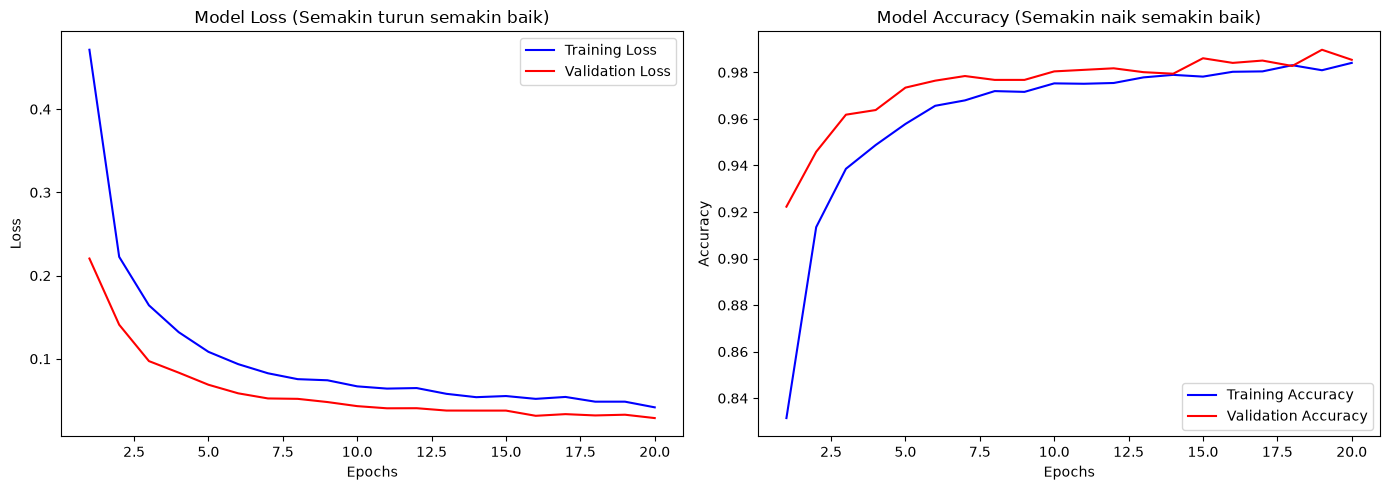

In [14]:
import matplotlib.pyplot as plt

# Ekstrak nilai history dari proses training
loss = history.history['loss']
val_loss = history.history['val_loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs_range = range(1, len(loss) + 1)

plt.figure(figsize=(14, 5))

# Plot Grafik Loss (Train vs Val)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
plt.title('Model Loss (Semakin turun semakin baik)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Grafik Akurasi (Train vs Val)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, accuracy, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy', color='red')
plt.title('Model Accuracy (Semakin naik semakin baik)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## 5. Menyimpan Model dan Scaler


In [15]:
print("Menyimpan model ke 'model.h5' dan scaler ke 'scaler.pkl'...")
model.save('model.h5')
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
    
print("Proses selesai. Model dan Scaler siap digunakan!")

Menyimpan model ke 'model.h5' dan scaler ke 'scaler.pkl'...
Proses selesai. Model dan Scaler siap digunakan!
